In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv(
    "../data/processed/cleaned_customer_churn.csv"
)

print("Dataset loaded successfully!")

print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# Basic Information

In [20]:
print("Dataset Information:")
print()

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     70

# Statistical Summary

In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


# Churn Distribution

In [22]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [23]:
churn_percentage = df["Churn"].value_counts(
    normalize=True
) * 100

print(churn_percentage)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


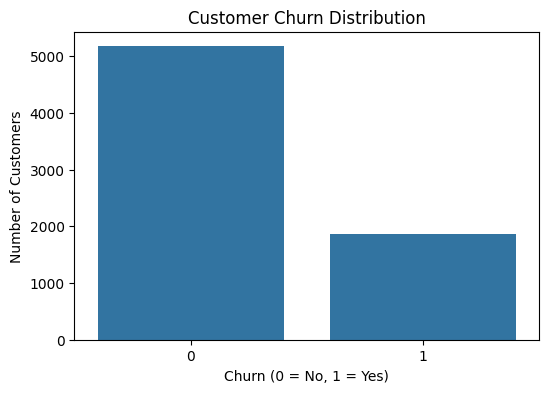

In [24]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn (0 = No, 1 = Yes)")

plt.ylabel("Number of Customers")

plt.show()

# Churn by Contract Type

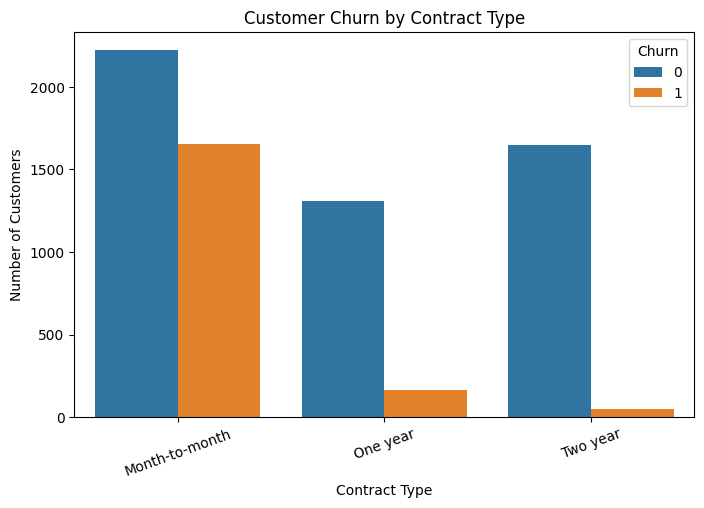

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")

plt.xlabel("Contract Type")

plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

# Churn vs Tenure

#### Ab check karte hain ke short-tenure customers zyada churn karte hain ya nahi.

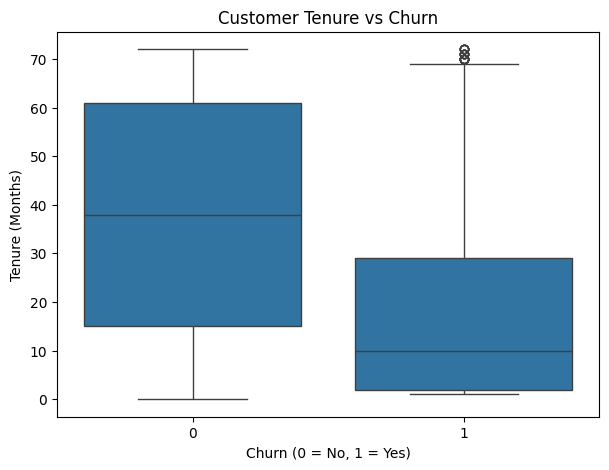

In [26]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure vs Churn")

plt.xlabel("Churn (0 = No, 1 = Yes)")

plt.ylabel("Tenure (Months)")

plt.show()

# Monthly Charges vs Churn

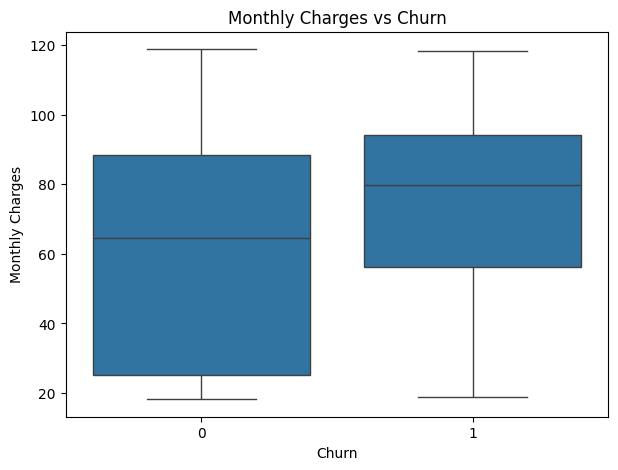

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.xlabel("Churn")

plt.ylabel("Monthly Charges")

plt.show()

# Churn by Internet Service

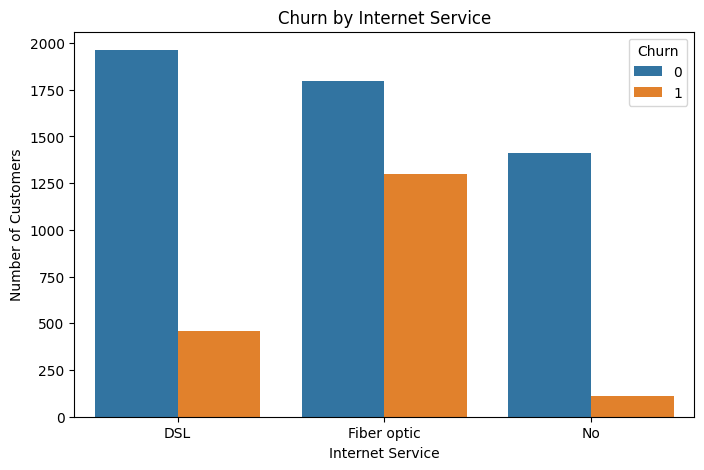

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")

plt.xlabel("Internet Service")

plt.ylabel("Number of Customers")

plt.show()

# Churn by Payment Method

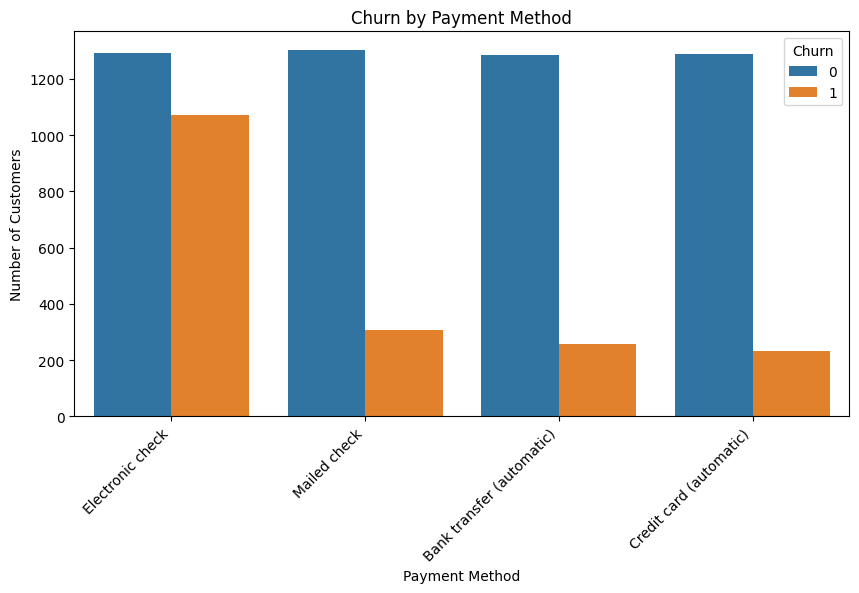

In [29]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn by Payment Method")

plt.xlabel("Payment Method")

plt.ylabel("Number of Customers")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.show()

# Churn by Senior Citizen

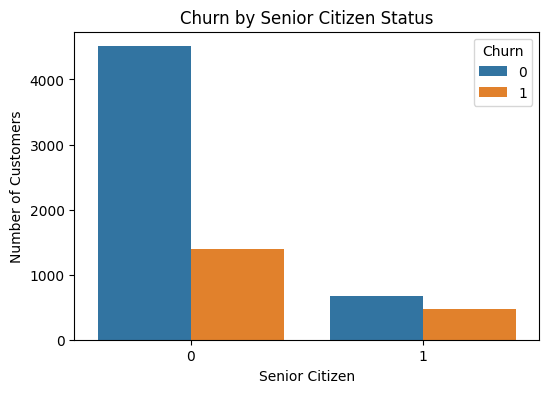

In [30]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Churn by Senior Citizen Status")

plt.xlabel("Senior Citizen")

plt.ylabel("Number of Customers")

plt.show()

# Correlation Matrix

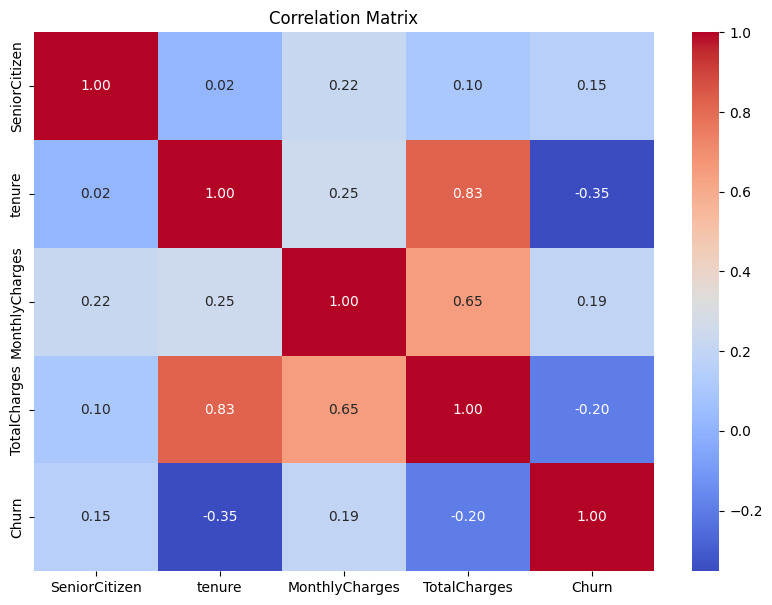

In [31]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Important Business Analysis

## Contract-wise churn rate

In [33]:
contract_churn = df.groupby(
    "Contract"
)["Churn"].mean() * 100

print(
    contract_churn.sort_values(
        ascending=False
    )
)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


## Internet service churn rate

In [34]:
internet_churn = df.groupby(
    "InternetService"
)["Churn"].mean() * 100

print(
    internet_churn.sort_values(
        ascending=False
    )
)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


## Payment method churn rate

In [35]:
payment_churn = df.groupby(
    "PaymentMethod"
)["Churn"].mean() * 100

print(
    payment_churn.sort_values(
        ascending=False
    )
)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64
